In [1]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/aqdam7/wholesale-dataset/Wholesale customers data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head())

(440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


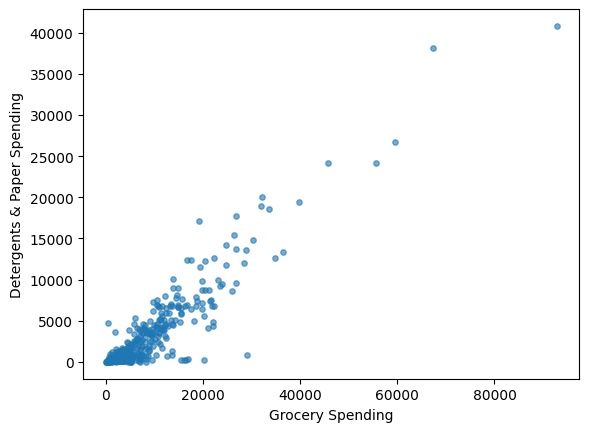

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Grocery"],
    df["Detergents_Paper"],
    s=15,
    alpha=0.6
)

plt.xlabel("Grocery Spending")
plt.ylabel("Detergents & Paper Spending")
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X_scaled = StandardScaler().fit_transform(
    df[feature_cols].values
)

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [5]:
df["Cluster"] = kmeans.predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
1    393
0     45
2      2
Name: count, dtype: int64


In [6]:
comparison = pd.crosstab(df["Cluster"], df["Channel"])

print(comparison)

Channel    1   2
Cluster         
0          1  44
1        295  98
2          2   0
